# Compare fitted values with external data

Produces Figure 4 in the paper

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import minimize
from tqdm import tqdm
import scipy.stats as stats
from numpy import linalg as LA
from matplotlib.patches import Ellipse
from scipy.stats import chi2
from scipy.interpolate import RectBivariateSpline
import math

In [2]:
# Define the differential equations for the epidemic model

def epidemic_model(t, y, lam, tau):
    P_ss, P_si, P_ii = y
    
    dP_ss = - 2 * lam * P_ss
    dP_si = 2 * lam * P_ss - lam * P_si - tau * P_si
    dP_ii = lam* P_si + tau * P_si
    
    return np.array([dP_ss, dP_si, dP_ii])

In [3]:
# Load previously estimated parameters
estimates = np.load("SI_pair_nongendered_model_estimates.npz")

xhat = estimates["xhat"]
covmat = estimates["covmat"]

print("Loaded xhat:")
print(xhat)

print("\nLoaded covmat:")
print(covmat)

Loaded xhat:
[0.00303465 0.05625516]

Loaded covmat:
[[1.63303961e-06 2.49658680e-05]
 [2.49658680e-05 2.17560815e-03]]


In [5]:
# Parameters estimated from your inference

lam_hat = xhat[0]
tau_hat = xhat[1]

# Initial conditions for validation

initial_state_validation = np.array([2113, 221, 131])

# Total number of pairs
total_pairs_validation = np.sum(initial_state_validation)

# Actual second observation

observed_second = np.array([2056, 221, 188])

# Simulate the deterministic model for 9 years

T_validation = 9.0

odefun_validation = lambda t, x: epidemic_model(
    t, x, lam_hat, tau_hat
)

sol_validation = solve_ivp(
    odefun_validation,
    (0, T_validation),
    initial_state_validation,
    t_eval=[T_validation]
)

# Expected numbers at year 9
expected_second = sol_validation.y[:, -1]

print("\nExpected numbers at 9 years:")
print("SS =", expected_second[0])
print("SI =", expected_second[1])
print("II =", expected_second[2])

print("\nObserved numbers at 9 years:")
print("SS =", observed_second[0])
print("SI =", observed_second[1])
print("II =", observed_second[2])


# Convert expected numbers to probabilities

probabilities = expected_second / total_pairs_validation

# Numerical protection
probabilities = probabilities / probabilities.sum()

print("\nProbabilities at 9 years:")
print(probabilities)

# Run stochastic simulations

n_simulations = 1000000

simulated_data = np.zeros(
    (n_simulations, 3),
    dtype=int
)

for i in tqdm(range(n_simulations)):
    
    xx = np.random.multivariate_normal(xhat,covmat)
    xx[xx<0] = 0
    lam = xx[0]
    tau = xx[1]
    
    odefun_validation = lambda t, x: epidemic_model(
    t, x, lam, tau
    )
    
    sol_validation = solve_ivp(
        odefun_validation,
        (0, T_validation),
        initial_state_validation,
        t_eval=[T_validation]
    )

    expected_second = sol_validation.y[:, -1]

    if (expected_second[2] < initial_state_validation[2]):
        print(expected_second)
        print(initial_state_validation)
    
    simulated_data[i, :] = expected_second 

# Look at the simulated values

print("\nFirst 10 simulations:")
print(simulated_data[:10])


print("\nMean simulated values:")
print(simulated_data.mean(axis=0))

print("\nStandard deviations:")
print(simulated_data.std(axis=0))


Expected numbers at 9 years:
SS = 2000.6757643675996
SI = 216.447492917418
II = 247.87674271498236

Observed numbers at 9 years:
SS = 2056
SI = 221
II = 188

Probabilities at 9 years:
[0.81163317 0.08780831 0.10055852]


100%|██████████████████████████████████████████████████████████| 1000000/1000000 [02:55<00:00, 5687.34it/s]



First 10 simulations:
[[1930  234  300]
 [2034  133  297]
 [1970  175  318]
 [2079  130  255]
 [2064  266  133]
 [1970  130  363]
 [2022  215  227]
 [2047  282  134]
 [1953  337  174]
 [1984  227  253]]

Mean simulated values:
[2000.587718  219.86425   243.056169]

Standard deviations:
[45.64647914 57.56261304 68.31430985]


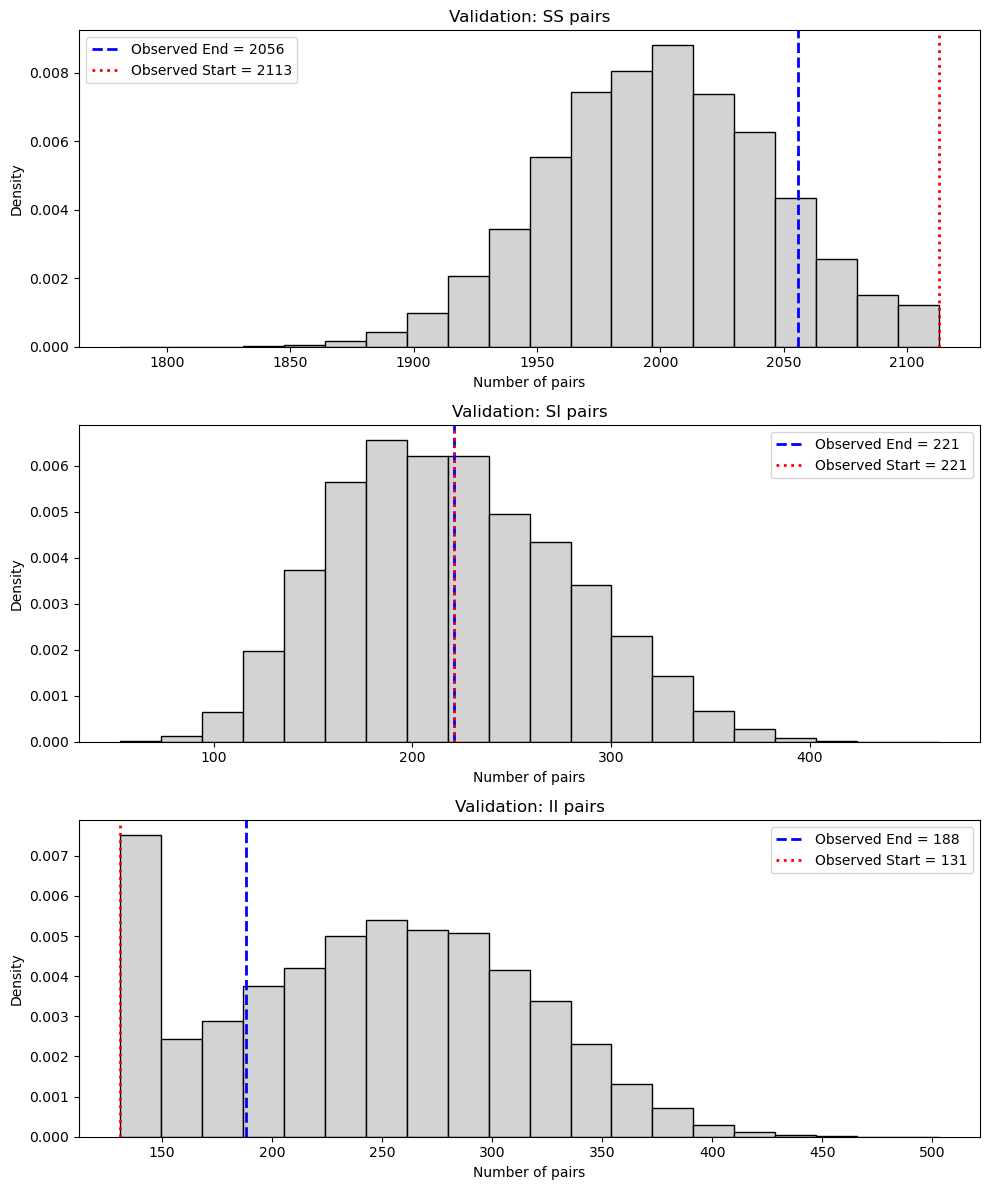

In [6]:
# Plot histograms

compartment_names = ["SS pairs", "SI pairs", "II pairs"]

fig, axes = plt.subplots(3, 1, figsize=(10, 12))

for j, (ax, name) in enumerate(zip(axes, compartment_names)):

    # Histogram
    ax.hist(
        simulated_data[:, j],
        bins=20,
        edgecolor="black",
        facecolor="lightgray",
        density=True,
    )

    # Actual observed value
    ax.axvline(
        observed_second[j],
        linestyle="--",
        linewidth=2,
        label=f"Observed End = {observed_second[j]}",
        color='b',
    )
    
    # Observed starting point
    ax.axvline(
        initial_state_validation[j],
        linestyle=":",
        linewidth=2,
        label=f"Observed Start = {initial_state_validation[j]}",
        color='r',
    )
    ax.set_xlabel("Number of pairs")
    ax.set_ylabel("Density")
    ax.set_title(f"Validation: {name}")
    ax.legend()

plt.tight_layout()

plt.savefig('./Figure4.pdf')